# Analyse de VaR pour un portefeuille

## Portefeuille TSLA / AMD / NVDA

Ce projet calcule la **Value at Risk (VaR)** d'un portefeuille actions par trois méthodes différentes (historique, paramétrique, Monte Carlo), puis valide le résultat par backtesting.

##1. Installation et imports

Installation de `yfinance` (récupération de données boursières) et des librairies de calcul standard.

In [13]:
!pip install yfinance -q
import yfinance as yf
import pandas as pd
import numpy as np

##2. Récupération des données

J'ai choisi trois actions du secteur technologique — Tesla (TSLA), AMD et Nvidia (NVDA) — sur une période de 2 ans (septembre 2024 à septembre 2026). Ces valeurs sont connues pour leur forte volatilité, ce qui permet d'observer des résultats de VaR significatifs et de bien illustrer la méthodologie sur un cas concret plutôt que sur un portefeuille peu risqué.

In [14]:
data = yf.download(["TSLA", "AMD", "NVDA"], start="2024-09-27", end="2026-09-27")
data.head()
close_prices = data["Close"]
close_prices.head()

/tmp/ipykernel_747/802832411.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["TSLA", "AMD", "NVDA"], start="2024-09-27", end="2026-09-27")
[*********************100%***********************]  3 of 3 completed


Ticker,AMD,NVDA,TSLA
Date,,,
2024-09-27,164.350006,121.075119,260.459991
2024-09-30,164.080002,121.115028,261.630005
2024-10-01,159.750000,116.686890,258.019989
2024-10-02,159.779999,118.531952,249.020004
2024-10-03,162.850006,122.521248,240.660004


##3. Calcul des rendements

On calcule le rendement journalier de chaque action avec la formule (Prix_jour - Prix_veille) / Prix_veille, exprimé en pourcentage plutôt qu'en variation absolue. Cela rend les actions comparables entre elles (une variation de 5$ n'a pas le même poids selon le niveau du prix) et donne une série statistiquement stable (stationnaire), contrairement aux prix bruts qui suivent une tendance dans le temps — c'est cette propriété qui permet de calculer ensuite une moyenne, un écart-type et une VaR.

In [15]:
returns = close_prices.pct_change().dropna()
returns.head()
returns.describe()


Ticker,AMD,NVDA,TSLA
count,499.000000,499.000000,499.000000
mean,0.003474,0.001630,0.001416
std,0.039891,0.027806,0.037696
min,-0.173144,-0.169682,-0.154262
25%,-0.018913,-0.013561,-0.019283
50%,0.001506,0.002368,0.000159
75%,0.022059,0.017686,0.022740
max,0.238205,0.187227,0.226900


##4. Construction du portefeuille

Le portefeuille est construit avec une pondération égale entre les trois actions (1/3 chacune), un choix simple qui permet de se concentrer sur la méthodologie de calcul de la VaR plutôt que sur un problème d'allocation optimale. Cette pondération suppose implicitement un rééquilibrage quotidien du portefeuille à 1/3-1/3-1/3 : en pratique, sans rééquilibrage, les poids dériveraient progressivement en fonction de la performance relative de chaque action.

In [16]:
weights = np.array([1/3, 1/3, 1/3])
portfolio_returns = returns.dot(weights)
portfolio_returns.head()

,0
Date,
2024-09-30,0.001060
2024-10-01,-0.025583
2024-10-02,-0.006294
2024-10-03,0.006433
2024-10-04,0.035141


##5. VaR historique

La VaR historique consiste à prendre directement le 5e percentile des rendements observés du portefeuille : c'est le seuil en dessous duquel se trouvent les 5% pires jours de l'historique. Concrètement, on estime qu'il y a 5% de chances que le portefeuille perde plus que cette valeur sur une journée, sans faire d'hypothèse sur la forme de la distribution des rendements.

In [17]:
var_95 = np.percentile(portfolio_returns, 5)
print(f"VaR 95% (1 jour) : {var_95:.2%}")
print(f"En euros sur 100 000 € : {var_95 * 100000:,.0f} €")


VaR 95% (1 jour) : -4.26%
En euros sur 100 000 € : -4,256 €


##6. VaR paramétrique

Ici on suppose que les rendements du portefeuille suivent une loi normale, et on calcule le seuil avec sa moyenne (μ) et son écart-type (σ) : `VaR = μ + z × σ`. Le terme z correspond au point de la loi normale sous lequel se trouvent 5% des cas (z ≈ -1,645 pour un seuil à 95%).

In [18]:
from scipy.stats import norm

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z = norm.ppf(0.05)

var_95_param = mu + z * sigma
print(f"z (95%) : {z:.3f}")
print(f"VaR paramétrique 95% (1 jour) : {var_95_param:.2%}")
print(f"En euros sur 100 000 € : {var_95_param * 100000:,.0f} €")

z (95%) : -1.645
VaR paramétrique 95% (1 jour) : -4.41%
En euros sur 100 000 € : -4,408 €


## 6bis. Comparaison à 99% : effet des queues épaisses

L'écart entre VaR historique et paramétrique reste faible à 95% (-4,26% vs -4,41%), mais se creuse nettement à 99% (-7,40% vs -6,32%). Cela illustre concrètement la limite de l'hypothèse de loi normale : les vrais rendements ont des "queues épaisses" (fat tails), c'est-à-dire que les pertes extrêmes sont plus fréquentes que ne le prévoit une distribution normale parfaite.

In [19]:
var_99_hist = np.percentile(portfolio_returns, 1)
var_99_param = mu + norm.ppf(0.01) * sigma
print(f"VaR 99% historique  : {var_99_hist:.2%}")
print(f"VaR 99% paramétrique : {var_99_param:.2%}")

VaR 99% historique  : -7.40%
VaR 99% paramétrique : -6.32%


7. VaR Monte Carlo

La VaR Monte Carlo simule 100 000 scénarios de rendements possibles à partir de la moyenne et de la matrice de covariance des 3 actions (qui capture le fait qu'elles ne bougent pas indépendamment), puis prend le 5e percentile des rendements de portefeuille simulés. Une seconde version utilise un bootstrap : au lieu de simuler depuis une loi normale théorique, on ré-échantillonne au hasard parmi les vrais rendements observés, ce qui capture mieux les queues épaisses de la distribution réelle.

In [20]:
mean_vec = returns.mean().values
cov_matrix = returns.cov().values

np.random.seed(42)
n_sims = 100_000
sim_returns = np.random.multivariate_normal(mean_vec, cov_matrix, n_sims)
sim_portfolio = sim_returns.dot(weights)

var_95_mc = np.percentile(sim_portfolio, 5)
print(f"VaR Monte Carlo 95% : {var_95_mc:.2%}")
np.random.seed(42)
n_sims = 100_000
sampled_returns = returns.sample(n=n_sims, replace=True).values
sim_portfolio_boot = sampled_returns.dot(weights)
var_95_boot = np.percentile(sim_portfolio_boot, 5)
print(f"VaR Monte Carlo (bootstrap historique) 95% : {var_95_boot:.2%}")

VaR Monte Carlo 95% : -4.42%
VaR Monte Carlo (bootstrap historique) 95% : -4.25%


8. Backtesting

Pour vérifier que la VaR est fiable, on compte le nombre de fois où le rendement réel du portefeuille a dépassé (à la baisse) le seuil de VaR historique à 95%. Si le modèle est bien calibré, ce taux de dépassement doit être proche de 5% — un taux beaucoup plus élevé indiquerait que la VaR sous-estime le risque réel.

In [21]:
breaches = portfolio_returns < var_95
n_breaches = breaches.sum()
n_days = len(portfolio_returns)
breach_rate = n_breaches / n_days
print(f"Dépassements : {n_breaches} sur {n_days} jours ({breach_rate:.2%})")
print(f"Taux attendu : 5.00%")

Dépassements : 25 sur 499 jours (5.01%)
Taux attendu : 5.00%


9. Visualisation

Ce graphique superpose trois éléments : la courbe des rendements journaliers du portefeuille, la ligne de seuil de la VaR historique à 95%, et les points rouges marquant chaque dépassement. On observe plusieurs pics de rendement, ainsi que des dépassements ponctuels du seuil, mais leur fréquence reste cohérente avec les 5% attendus par construction.

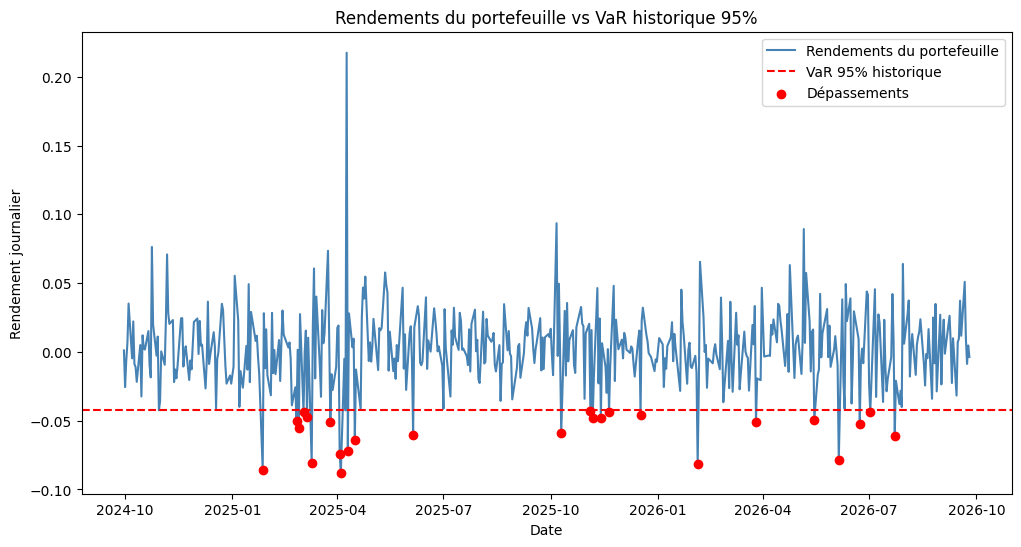

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns.index, portfolio_returns, label="Rendements du portefeuille", color="steelblue")
plt.axhline(y=var_95, color="red", linestyle="--", label="VaR 95% historique")
plt.scatter(portfolio_returns.index[breaches], portfolio_returns[breaches], color="red", zorder=5, label="Dépassements")
plt.title("Rendements du portefeuille vs VaR historique 95%")
plt.xlabel("Date")
plt.ylabel("Rendement journalier")
plt.legend()
plt.show()

## Conclusion

| Méthode | VaR 95% (1 jour) | VaR 99% (1 jour) |
|---|---|---|
| Historique | -4.26% | -7.40% |
| Paramétrique | -4.41% | -6.32% |
| Monte Carlo (normal) | -4.42% | — |
| Monte Carlo (bootstrap) | -4.25% | — |

**Backtesting** : le taux de dépassement observé (5.01% sur 499 jours) correspond quasiment exactement au seuil théorique de 5%, confirmant que la VaR historique est bien calibrée sur cette période.

**Synthèse** : les quatre méthodes convergent à 95% (écart maximal de 0,2 point), ce qui valide la cohérence de l'implémentation. L'écart se creuse en revanche à 99% (-7.40% contre -6.32%), illustrant une limite connue de l'hypothèse de loi normale : elle sous-estime la fréquence des pertes extrêmes (*fat tails*). Ce projet montre ainsi non seulement la capacité à implémenter plusieurs méthodes de calcul de VaR, mais aussi à en identifier les limites et à les valider empiriquement par backtesting — une démarche proche de ce qu'attend une fonction risque sur un desk.

In [23]:
close_prices.to_csv("prix_actions.csv")
returns.to_csv("rendements.csv")

## 8. Backtest hors échantillon (fenêtre glissante) et test de Kupiec

### Le problème du backtest précédent

Dans la partie 7, la VaR historique est le 5e percentile des 499 rendements, puis on compte combien de ces **mêmes** 499 rendements passent sous ce seuil. Par définition d'un percentile à 5%, on trouve environ 5% de dépassements (25 sur 499) : le résultat est vrai **par construction**, quel que soit le modèle. Le test ne prouve donc rien sur la qualité de la VaR.

### La correction : un vrai test hors échantillon

Un backtest valide reproduit ce que ferait un risk manager au quotidien :
1. chaque jour t, on calcule la VaR avec **uniquement les 250 derniers jours connus** (environ 1 an de bourse) ;
2. on compare cette VaR au rendement **réel du jour t**, que le modèle n'a jamais vu ;
3. on fait glisser la fenêtre d'un jour et on recommence.

Le `.shift(1)` est la ligne clé : sans lui, la VaR du jour t inclurait le rendement du jour t, et on retomberait dans la circularité (biais de look-ahead, le même que dans le projet momentum).

On compte ensuite les **dépassements** (jours où la perte réelle dépasse la VaR). Avec 95% de confiance, on en attend 5% des jours testés, mais cette fois ce n'est plus automatique : si le modèle sous-estime le risque, on verra nettement plus.

Comme il faut 250 jours pour calculer la première VaR, il reste 499 − 250 = **249 jours de test**.

In [24]:
window = 250                       # taille de la fenêtre d'estimation : ~1 an de jours de bourse

results = {}                       # on stockera ici les résultats de chaque méthode et niveau de confiance

for conf in [0.95, 0.99]:          # on teste les deux niveaux de confiance utilisés dans le projet
    p = 1 - conf                   # probabilité de queue : 5% pour 95%, 1% pour 99%

    # VaR historique glissante : percentile p des 250 derniers rendements
    # .shift(1) décale d'un jour : la VaR utilisée le jour t ne contient que des données jusqu'à t-1 (pas de look-ahead)
    var_hist_roll = portfolio_returns.rolling(window).quantile(p).shift(1)

    # VaR paramétrique glissante : moyenne + z * écart-type, estimés sur les 250 derniers jours
    # norm.ppf(p) = quantile de la loi normale (négatif : -1.645 pour 5%, -2.326 pour 1%)
    var_param_roll = (portfolio_returns.rolling(window).mean()
                      + norm.ppf(p) * portfolio_returns.rolling(window).std()).shift(1)

    for name, var_roll in [("Historique", var_hist_roll), ("Paramétrique", var_param_roll)]:
        valid = var_roll.notna()                            # les 250 premiers jours n'ont pas de VaR : on les écarte
        breaches = portfolio_returns[valid] < var_roll[valid]   # True si la perte réelle dépasse la VaR du jour
        n = valid.sum()                                      # nombre de jours testés (249)
        x = breaches.sum()                                   # nombre de dépassements observés
        results[(name, conf)] = (n, x)                       # on garde (jours testés, dépassements) pour le test de Kupiec
        print(f"{name:13s} {conf:.0%} | {x} dépassements sur {n} jours = {x/n:.2%} (attendu : {p:.0%})")

Historique    95% | 12 dépassements sur 249 jours = 4.82% (attendu : 5%)
Paramétrique  95% | 12 dépassements sur 249 jours = 4.82% (attendu : 5%)
Historique    99% | 3 dépassements sur 249 jours = 1.20% (attendu : 1%)
Paramétrique  99% | 3 dépassements sur 249 jours = 1.20% (attendu : 1%)


### Le test de Kupiec (Proportion Of Failures)

On observe 12 dépassements sur 249 jours (4,82 %) alors qu'on en attendait 5 %. Est-ce compatible avec un modèle correct, ou le modèle est-il mal calibré ? Avec si peu de jours, un petit écart peut être du pur hasard. Le test de Kupiec répond à cette question avec une règle statistique.

**Hypothèse testée (H0)** : la vraie probabilité de dépassement est bien p (5 % ou 1 %).

**Principe** : on compare deux vraisemblances.
- celle des données si la probabilité de dépassement vaut exactement p (le modèle est correct) ;
- celle des données si la probabilité vaut le taux observé x/n (la meilleure explication possible des données).

La statistique est LR = −2 × [ln L(p) − ln L(x/n)]. Plus le taux observé s'éloigne de p, plus LR grandit. Sous H0, LR suit une loi du khi-deux à 1 degré de liberté.

**Lecture** :
- LR < 3,84 (p-value > 5 %) : on ne rejette pas le modèle, l'écart est compatible avec le hasard ;
- LR > 3,84 (p-value < 5 %) : on rejette le modèle, il sous-estime ou sur-estime le risque.

**Attention à la conclusion** : « on ne rejette pas » ne veut pas dire « le modèle est prouvé bon ». Avec 249 jours, le test a peu de puissance, surtout à 99 % où on attend seulement 2 à 3 dépassements. C'est la nuance à dire en entretien.

In [25]:
from scipy.stats import chi2          # loi du khi-deux, utilisée pour convertir LR en p-value

def kupiec_test(x, n, p):
    # x = nombre de dépassements observés, n = nombre de jours testés, p = taux de dépassement attendu
    taux_obs = x / n                   # taux de dépassement observé (ex. 12/249 = 4.82%)

    # log-vraisemblance si le modèle est correct (probabilité de dépassement = p)
    ll_h0 = (n - x) * np.log(1 - p) + x * np.log(p)

    # log-vraisemblance avec le taux observé ; si x = 0, le terme x*log(taux_obs) vaut 0 par convention
    if x == 0:
        ll_h1 = n * np.log(1 - taux_obs)
    else:
        ll_h1 = (n - x) * np.log(1 - taux_obs) + x * np.log(taux_obs)

    lr = -2 * (ll_h0 - ll_h1)          # statistique du test : grande si le taux observé s'écarte de p
    p_value = 1 - chi2.cdf(lr, df=1)   # probabilité d'obtenir un LR au moins aussi grand si H0 est vraie
    return lr, p_value

lignes = []                            # on construit un tableau récapitulatif
for (methode, conf), (n, x) in results.items():      # on réutilise les résultats de la cellule précédente
    p = 1 - conf                                      # taux attendu : 5% ou 1%
    lr, pv = kupiec_test(x, n, p)
    lignes.append({
        "Méthode": methode,
        "Confiance": f"{conf:.0%}",
        "Dépassements": f"{x}/{n}",
        "Taux observé": f"{x/n:.2%}",
        "Taux attendu": f"{p:.0%}",
        "LR": round(lr, 3),
        "p-value": round(pv, 3),
        "Verdict": "Non rejeté" if pv > 0.05 else "Rejeté",   # seuil de 5%
    })

tableau_kupiec = pd.DataFrame(lignes)
print(tableau_kupiec.to_string(index=False))

     Méthode Confiance Dépassements Taux observé Taux attendu    LR  p-value    Verdict
  Historique       95%       12/249        4.82%           5% 0.017    0.895 Non rejeté
Paramétrique       95%       12/249        4.82%           5% 0.017    0.895 Non rejeté
  Historique       99%        3/249        1.20%           1% 0.099    0.753 Non rejeté
Paramétrique       99%        3/249        1.20%           1% 0.099    0.753 Non rejeté


## Conclusion

### Ce que le projet a produit

Sur un portefeuille équipondéré de trois valeurs technologiques (TSLA, AMD, NVDA, 499 rendements journaliers du 27 septembre 2024 au 27 septembre 2026), on a calculé la VaR à 1 jour par quatre méthodes :

| Méthode | VaR 95 % | VaR 99 % |
|---|---|---|
| Historique | -4,26 % | -7,40 % |
| Paramétrique (loi normale) | -4,41 % | -6,32 % |
| Monte Carlo (loi normale) | -4,42 % | — |
| Monte Carlo (bootstrap) | -4,25 % | — |

### Ce qu'on en retient

1. **À 95 %, les quatre méthodes convergent** (entre -4,25 % et -4,42 %) : le choix de la méthode change peu le résultat.
2. **À 99 %, l'écart se creuse** : la VaR historique (-7,40 %) est nettement plus sévère que la paramétrique (-6,32 %). La loi normale sous-estime la probabilité des gros mouvements : ce sont les **queues épaisses**, caractéristiques des rendements d'actions.
3. **Le backtest initial n'était pas concluant.** Compter combien des 499 rendements passent sous le 5e percentile de ces mêmes 499 rendements donne ~5 % de dépassements par construction, quel que soit le modèle.
4. **Le backtest corrigé est hors échantillon** : VaR recalculée chaque jour sur les 250 derniers jours seulement (décalée d'un jour pour éviter le look-ahead), comparée au rendement réel du jour. Sur 249 jours testés : 4,82 % de dépassements à 95 % (attendu 5 %) et 1,20 % à 99 % (attendu 1 %). Le **test de Kupiec ne rejette pas le modèle** (p-values de 0,895 et 0,753).

### Limites

- **Puissance du test faible** : avec 249 jours, un « non rejeté » signifie « pas de preuve que le modèle est mauvais », pas « le modèle est validé ». C'est particulièrement vrai à 99 %, où l'on attend seulement 2 à 3 dépassements.
- **Kupiec ne teste que le nombre de dépassements, pas leur répartition dans le temps.** Les dépassements du portefeuille sont groupés en périodes de forte volatilité (clustering) : le test de Christoffersen, qui vérifie l'indépendance des dépassements, serait la suite logique.
- **Volatilité supposée constante** dans la fenêtre : un modèle de type EWMA ou GARCH s'adapterait mieux aux régimes de marché.
- **Portefeuille concentré sur trois valeurs technologiques** sur deux ans, avec rééquilibrage quotidien parfait supposé : les résultats ne se généralisent pas à un portefeuille diversifié.
- **VaR à 1 jour uniquement**, sans mesure de la perte au-delà du seuil : l'Expected Shortfall (ES), exigée par Bâle III pour les risques de marché, serait un complément naturel.